In [9]:
import pandas as pd

# Load the CSV file
file_path = "cisco.csv"  # Update with the correct file path
df = pd.read_csv(file_path)

# Trim spaces from column names (if any)
df.columns = df.columns.str.strip()

# Display the first few rows
print(df.head())


   Cost_Rank                   Product_Name Product_Life_Cycle  FY22_Q4  \
0          1        SWITCH Enterprise High          Sustaining    52870   
1          2  SWITCH Enterprise Ultra High          Sustaining     4619   
2          3  SWITCH Enterprise Ultra High          Sustaining    19067   
3          4          SWITCH Enterprise Low         Sustaining     1227   
4          5         TRANSCEIVER MODULE Mid         Sustaining   150803   

   FY23_Q1  FY23_Q2  FY23_Q3  FY23_Q4  FY24_Q1  FY24_Q2  ...  \
0    38833    27114    21823    31813    27302    22084  ...   
1     4764     5015     6656     9605     5956     8450  ...   
2    14551    13271    10165    10477     7295     8084  ...   
3    24186     7680    16772    17554    16095    26125  ...   
4    82163    82408    67132    87498    69599    78130  ...   

   SFY2024_Q3_Accuracy  SFY2024_Q3_BIAS  SFY2024_Q4_Accuracy SFY2024_Q4_BIAS  \
0               76.51%           23.49%               94.26%          -5.74%   
1   

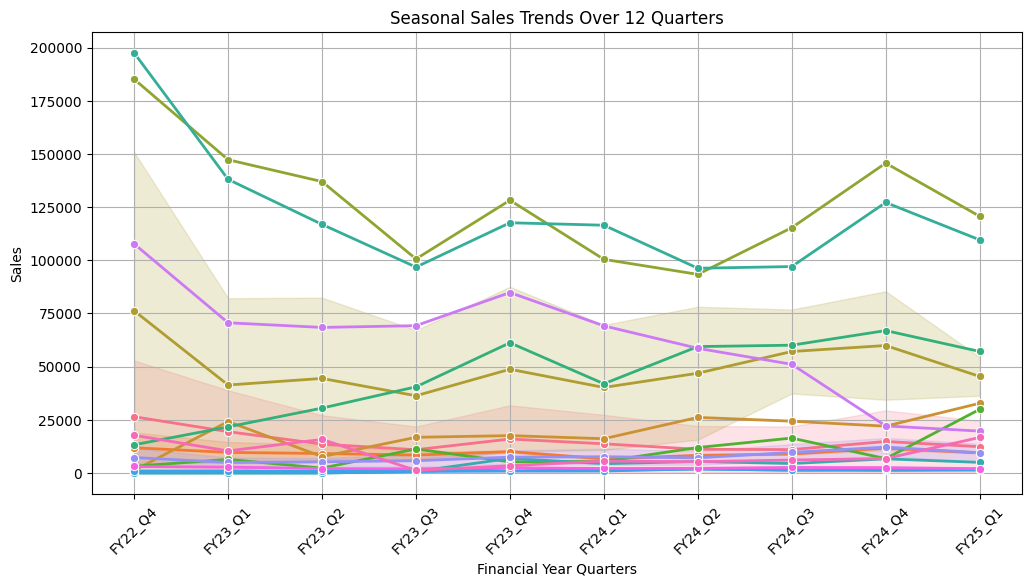

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
file_path = "cisco.csv"  # Update with the correct path
df = pd.read_csv(file_path)

# Trim spaces from column names
df.columns = df.columns.str.strip()

# Extract financial year quarter columns
quarters = ["FY22_Q4", "FY23_Q1", "FY23_Q2", "FY23_Q3", "FY23_Q4",
            "FY24_Q1", "FY24_Q2", "FY24_Q3", "FY24_Q4", "FY25_Q1"]

# Convert data to long format for easier plotting
df_melted = df.melt(id_vars=["Product_Name"], value_vars=quarters, var_name="Quarter", value_name="Sales")

# Plot the trends
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_melted, x="Quarter", y="Sales", hue="Product_Name", marker="o", linewidth=2)

# Formatting the plot
plt.xticks(rotation=45)
plt.xlabel("Financial Year Quarters")
plt.ylabel("Sales")
plt.title("Seasonal Sales Trends Over 12 Quarters")
plt.legend([],[], frameon=False)  # Hide legend if too many products
plt.grid(True)
plt.show()


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the CSV file
file_path = "cisco.csv"  # Update with the correct path
df = pd.read_csv(file_path)

# Trim spaces from column names
df.columns = df.columns.str.strip()

# Extract financial year quarter columns
quarters = ["FY22_Q4", "FY23_Q1", "FY23_Q2", "FY23_Q3", "FY23_Q4",
            "FY24_Q1", "FY24_Q2", "FY24_Q3", "FY24_Q4", "FY25_Q1"]

# Convert quarters to numerical index for time series analysis
df_time = df[["Product_Name"] + quarters].set_index("Product_Name").T
df_time.index = range(1, len(df_time) + 1)  # Convert quarters to numerical time index

# Plot decomposition for each product
for product in df_time.columns:
    sales_series = df_time[product].dropna()  # Ensure no missing values
    decomposition = seasonal_decompose(sales_series, model="additive", period=4)  # Quarterly seasonality

    # Plot decomposition
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    
    axes[0].plot(sales_series, label="Original Sales", color="blue", marker="o")
    axes[0].set_title(f"Sales Data for {product}")
    axes[0].legend()
    
    axes[1].plot(decomposition.trend, label="Trend", color="green", linewidth=2)
    axes[1].set_title("Trend")
    axes[1].legend()
    
    axes[2].plot(decomposition.seasonal, label="Seasonality", color="orange", linewidth=2)
    axes[2].set_title("Seasonality")
    axes[2].legend()
    
    axes[3].plot(decomposition.resid, label="Residuals", color="red", linewidth=2)
    axes[3].set_title("Residuals (Unexplained Variance)")
    axes[3].legend()
    
    plt.xlabel("Time (Quarters)")
    plt.tight_layout()
    plt.show()


TypeError: Index(...) must be called with a collection of some kind, 'seasonal' was passed

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the CSV file
file_path = "cisco.csv"  # Update with the correct path
df = pd.read_csv(file_path)

# Trim spaces from column names
df.columns = df.columns.str.strip()

# Define quarters (Ensure these match column names exactly)
quarters = ["FY22_Q4", "FY23_Q1", "FY23_Q2", "FY23_Q3", "FY23_Q4",
            "FY24_Q1", "FY24_Q2", "FY24_Q3", "FY24_Q4", "FY25_Q1"]

# Transpose data: Convert products to columns and quarters to rows (time series format)
df_time = df.set_index("Product_Name")[quarters].T  

# Create a proper time index with quarterly frequency
df_time.index = pd.date_range(start="2022-10-01", periods=len(df_time), freq="Q")  # Q means quarterly

# Loop through each product and perform seasonal decomposition
for product in df_time.columns:
    sales_series = df_time[product].dropna()  # Remove missing values
    
    # Ensure we have enough data (min 2 * period for decomposition)
    if len(sales_series) < 8:
        print(f"Skipping {product} due to insufficient data.")
        continue

    # Perform seasonal decomposition
    decomposition = seasonal_decompose(sales_series, model="additive", period=4)  # Quarterly seasonality

    # Plot decomposition
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    
    axes[0].plot(sales_series, label="Original Sales", color="blue", marker="o")
    axes[0].set_title(f"Sales Data for {product}")
    axes[0].legend()
    
    axes[1].plot(decomposition.trend, label="Trend", color="green", linewidth=2)
    axes[1].set_title("Trend")
    axes[1].legend()
    
    axes[2].plot(decomposition.seasonal, label="Seasonality", color="orange", linewidth=2)
    axes[2].set_title("Seasonality")
    axes[2].legend()
    
    axes[3].plot(decomposition.resid, label="Residuals", color="red", linewidth=2)
    axes[3].set_title("Residuals (Unexplained Variance)")
    axes[3].legend()
    
    plt.xlabel("Time (Quarters)")
    plt.tight_layout()
    plt.show()


C:\Users\suhas\AppData\Local\Temp\ipykernel_21668\731368111.py:20: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df_time.index = pd.date_range(start="2022-10-01", periods=len(df_time), freq="Q")  # Q means quarterly


TypeError: Index(...) must be called with a collection of some kind, 'seasonal' was passed

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the CSV file
file_path = "cisco.csv"  # Update with the correct path
df = pd.read_csv(file_path)

# Trim spaces from column names
df.columns = df.columns.str.strip()

# Define quarters (Ensure these match column names exactly)
quarters = ["FY22_Q4", "FY23_Q1", "FY23_Q2", "FY23_Q3", "FY23_Q4",
            "FY24_Q1", "FY24_Q2", "FY24_Q3", "FY24_Q4", "FY25_Q1"]

# Transpose data: Convert products to columns and quarters to rows (time series format)
df_time = df.set_index("Product_Name")[quarters].T  

# Ensure correct time index
df_time.index = pd.date_range(start="2022-10-01", periods=len(df_time), freq="Q")  # Q = Quarterly

# Debugging: Check if the index is properly set
print("Index type:", type(df_time.index))
print("First few rows:\n", df_time.head())

# Loop through each product and perform seasonal decomposition
for product in df_time.columns:
    sales_series = df_time[product].dropna()  # Remove missing values
    
    # Debugging: Check data format
    print(f"\nProcessing product: {product}")
    print(sales_series.head())

    # Ensure we have enough data for decomposition
    if len(sales_series) < 8:
        print(f"Skipping {product} due to insufficient data.")
        continue

    # Perform seasonal decomposition
    try:
        decomposition = seasonal_decompose(sales_series, model="additive", period=4)  # Quarterly seasonality
    except ValueError as e:
        print(f"Error decomposing {product}: {e}")
        continue

    # Plot decomposition
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    
    axes[0].plot(sales_series, label="Original Sales", color="blue", marker="o")
    axes[0].set_title(f"Sales Data for {product}")
    axes[0].legend()
    
    axes[1].plot(decomposition.trend, label="Trend", color="green", linewidth=2)
    axes[1].set_title("Trend")
    axes[1].legend()
    
    axes[2].plot(decomposition.seasonal, label="Seasonality", color="orange", linewidth=2)
    axes[2].set_title("Seasonality")
    axes[2].legend()
    
    axes[3].plot(decomposition.resid, label="Residuals", color="red", linewidth=2)
    axes[3].set_title("Residuals (Unexplained Variance)")
    axes[3].legend()
    
    plt.xlabel("Time (Quarters)")
    plt.tight_layout()
    plt.show()


Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
First few rows:
 Product_Name  SWITCH Enterprise High   SWITCH Enterprise Ultra High   \
2022-12-31                      52870                           4619   
2023-03-31                      38833                           4764   
2023-06-30                      27114                           5015   
2023-09-30                      21823                           6656   
2023-12-31                      31813                           9605   

Product_Name  SWITCH Enterprise Ultra High   SWITCH Enterprise Low  \
2022-12-31                            19067                   1227   
2023-03-31                            14551                  24186   
2023-06-30                            13271                   7680   
2023-09-30                            10165                  16772   
2023-12-31                            10477                  17554   

Product_Name  TRANSCEIVER MODULE Mid  POWER SUPPLY High  \
2022

C:\Users\suhas\AppData\Local\Temp\ipykernel_21668\1371594647.py:20: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df_time.index = pd.date_range(start="2022-10-01", periods=len(df_time), freq="Q")  # Q = Quarterly


TypeError: Index(...) must be called with a collection of some kind, 'seasonal' was passed

In [29]:
import pandas as pd

# Load the CSV file
file_path = "cisco.csv"  # Update with the correct path
df = pd.read_csv(file_path)

# Trim spaces from column names
df.columns = df.columns.str.strip()

# Define the 12 quarters (first 9 actual, last 3 predicted)
quarters = ["FY22_Q4", "FY23_Q1", "FY23_Q2", "FY23_Q3", "FY23_Q4",
            "FY24_Q1", "FY24_Q2", "FY24_Q3", "FY24_Q4", "FY25_Q1"]

# Extract actual sales (first 9 quarters)
actual_sales = df.set_index("Product_Name")[quarters[:9]]

# Extract forecasted accuracy and bias for the last 3 quarters
forecast_columns = ["DFY2024_Q3_Accuracy", "DFY2024_Q3_BIAS", "DFY2024_Q4_Accuracy", "DFY2024_Q4_BIAS", "DFY2025_Q1_Accuracy", "DFY2025_Q1_BIAS",
                    "MFY2024_Q3_Accuracy", "MFY2024_Q3_BIAS", "MFY2024_Q4_Accuracy", "MFY2024_Q4_BIAS", "MFY2025_Q1_Accuracy", "MFY2025_Q1_BIAS",
                    "SFY2024_Q3_Accuracy", "SFY2024_Q3_BIAS", "SFY2024_Q4_Accuracy", "SFY2024_Q4_BIAS", "SFY2025_Q1_Accuracy", "SFY2025_Q1_BIAS"]

forecast_data = df.set_index("Product_Name")[forecast_columns]

# Convert percentage strings to float
def convert_percentage(value):
    if isinstance(value, str) and value.endswith('%'):
        return float(value.strip('%'))
    return float(value)  # Ensure numeric conversion

forecast_data = forecast_data.applymap(convert_percentage)

# Determine best-performing team for each product
def determine_best_team(row):
    teams = {
        "Demand": row[["DFY2024_Q3_Accuracy", "DFY2024_Q4_Accuracy", "DFY2025_Q1_Accuracy"]],
        "Marketing": row[["MFY2024_Q3_Accuracy", "MFY2024_Q4_Accuracy", "MFY2025_Q1_Accuracy"]],
        "Statistics": row[["SFY2024_Q3_Accuracy", "SFY2024_Q4_Accuracy", "SFY2025_Q1_Accuracy"]]
    }
    
    avg_accuracy = {team: values.mean() for team, values in teams.items()}
    best_team = max(avg_accuracy, key=avg_accuracy.get)
    return best_team

# Apply function to determine best team for each product
forecast_data["Best_Team"] = forecast_data.apply(determine_best_team, axis=1)

# Display results
print(forecast_data[["Best_Team"]])

                                Best_Team
Product_Name                             
SWITCH Enterprise High             Demand
SWITCH Enterprise Ultra High       Demand
SWITCH Enterprise Ultra High       Demand
SWITCH Enterprise Low              Demand
TRANSCEIVER MODULE Mid         Statistics
POWER SUPPLY High                  Demand
TRANSCEIVER MODULE High        Statistics
ACCESS POINT Mid                   Demand
POWER SUPPLY Mid               Statistics
SERVER                         Statistics
PROCESSOR                          Demand
SWITCH Data Center High            Demand
TRANSCEIVER MODULE Mid             Demand
ROUTER Enterprise Mid           Marketing
MEMORY                             Demand
ROUTER Enterprise Mid           Marketing
SWITCH Data Center Mid         Statistics
ROUTER Enterprise Low              Demand
SWITCH Data Center Mid         Statistics
SWITCH Enterprise High             Demand


C:\Users\suhas\AppData\Local\Temp\ipykernel_21668\135539622.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  forecast_data = forecast_data.applymap(convert_percentage)


In [31]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the CSV file
file_path = "cisco.csv"  # Update with the correct path
df = pd.read_csv(file_path)

# Trim spaces from column names
df.columns = df.columns.str.strip()

# Define the 12 quarters (first 9 actual, last 3 predicted)
quarters = ["FY22_Q4", "FY23_Q1", "FY23_Q2", "FY23_Q3", "FY23_Q4",
            "FY24_Q1", "FY24_Q2", "FY24_Q3", "FY24_Q4", "FY25_Q1"]

# Extract actual sales (all 12 quarters)
actual_sales = df.set_index("Product_Name")[quarters]

# Extract forecasted accuracy and bias for the last 3 quarters
forecast_columns = ["DFY2024_Q3_Accuracy", "DFY2024_Q3_BIAS", "DFY2024_Q4_Accuracy", "DFY2024_Q4_BIAS", "DFY2025_Q1_Accuracy", "DFY2025_Q1_BIAS",
                    "MFY2024_Q3_Accuracy", "MFY2024_Q3_BIAS", "MFY2024_Q4_Accuracy", "MFY2024_Q4_BIAS", "MFY2025_Q1_Accuracy", "MFY2025_Q1_BIAS",
                    "SFY2024_Q3_Accuracy", "SFY2024_Q3_BIAS", "SFY2024_Q4_Accuracy", "SFY2024_Q4_BIAS", "SFY2025_Q1_Accuracy", "SFY2025_Q1_BIAS"]

forecast_data = df.set_index("Product_Name")[forecast_columns]

# Convert percentage strings to float
def convert_percentage(value):
    if isinstance(value, str) and value.endswith('%'):
        return float(value.strip('%'))
    return float(value)  # Ensure numeric conversion

forecast_data = forecast_data.applymap(convert_percentage)

# Determine best-performing team for each product
def determine_best_team(row):
    teams = {
        "Demand": row[["DFY2024_Q3_Accuracy", "DFY2024_Q4_Accuracy", "DFY2025_Q1_Accuracy"]],
        "Marketing": row[["MFY2024_Q3_Accuracy", "MFY2024_Q4_Accuracy", "MFY2025_Q1_Accuracy"]],
        "Statistics": row[["SFY2024_Q3_Accuracy", "SFY2024_Q4_Accuracy", "SFY2025_Q1_Accuracy"]]
    }
    
    avg_accuracy = {team: values.mean() for team, values in teams.items()}
    best_team = max(avg_accuracy, key=avg_accuracy.get)
    return best_team

# Apply function to determine best team for each product
forecast_data["Best_Team"] = forecast_data.apply(determine_best_team, axis=1)

# Predict next quarter (FY25_Q2) using seasonality trend
def predict_next_quarter(product_sales):
    product_sales = product_sales.dropna()
    decomposition = seasonal_decompose(product_sales, model='additive', period=4)
    trend = decomposition.trend.dropna()
    seasonal = decomposition.seasonal.dropna()
    predicted_value = trend.iloc[-1] + seasonal.iloc[-1]
    return predicted_value

# Apply prediction for each product
actual_sales["FY25_Q2_Predicted"] = actual_sales.apply(predict_next_quarter, axis=1)

# Display results
print(actual_sales[["FY25_Q2_Predicted"]])


                               FY25_Q2_Predicted
Product_Name                                    
SWITCH Enterprise High              26908.328125
SWITCH Enterprise Ultra High         7506.781250
SWITCH Enterprise Ultra High         7866.390625
SWITCH Enterprise Low               21165.765625
TRANSCEIVER MODULE Mid              69212.765625
POWER SUPPLY High                  111586.265625
TRANSCEIVER MODULE High             10098.125000
ACCESS POINT Mid                    46812.062500
POWER SUPPLY Mid                   119989.703125
SERVER                               4591.328125
PROCESSOR                             991.640625
SWITCH Data Center High              1338.843750
TRANSCEIVER MODULE Mid              24295.578125
ROUTER Enterprise Mid               13880.875000
MEMORY                              42006.515625
ROUTER Enterprise Mid                5307.953125
SWITCH Data Center Mid               1645.984375
ROUTER Enterprise Low                8717.546875
SWITCH Data Center M

C:\Users\suhas\AppData\Local\Temp\ipykernel_21668\1609528601.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  forecast_data = forecast_data.applymap(convert_percentage)


In [35]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the CSV file
file_path = "cisco.csv"  # Update with the correct path
df = pd.read_csv(file_path)

# Trim spaces from column names
df.columns = df.columns.str.strip()

# Define the 12 quarters (first 9 actual, last 3 predicted)
quarters = ["FY22_Q4", "FY23_Q1", "FY23_Q2", "FY23_Q3", "FY23_Q4",
            "FY24_Q1", "FY24_Q2", "FY24_Q3", "FY24_Q4", "FY25_Q1"]

# Extract actual sales (all 12 quarters)
actual_sales = df.set_index("Product_Name")[quarters]

# Extract forecasted accuracy and bias for the last 3 quarters
forecast_columns = ["DFY2024_Q3_Accuracy", "DFY2024_Q3_BIAS", "DFY2024_Q4_Accuracy", "DFY2024_Q4_BIAS", "DFY2025_Q1_Accuracy", "DFY2025_Q1_BIAS",
                    "MFY2024_Q3_Accuracy", "MFY2024_Q3_BIAS", "MFY2024_Q4_Accuracy", "MFY2024_Q4_BIAS", "MFY2025_Q1_Accuracy", "MFY2025_Q1_BIAS",
                    "SFY2024_Q3_Accuracy", "SFY2024_Q3_BIAS", "SFY2024_Q4_Accuracy", "SFY2024_Q4_BIAS", "SFY2025_Q1_Accuracy", "SFY2025_Q1_BIAS"]

forecast_data = df.set_index("Product_Name")[forecast_columns]

# Convert percentage strings to float
def convert_percentage(value):
    if isinstance(value, str) and value.endswith('%'):
        return float(value.strip('%')) / 100
    return float(value)  # Ensure numeric conversion

forecast_data = forecast_data.applymap(convert_percentage)

# Determine best-performing team for each product
def determine_best_team(row):
    teams = {
        "Demand": row[["DFY2024_Q3_Accuracy", "DFY2024_Q4_Accuracy", "DFY2025_Q1_Accuracy"]].mean(),
        "Marketing": row[["MFY2024_Q3_Accuracy", "MFY2024_Q4_Accuracy", "MFY2025_Q1_Accuracy"]].mean(),
        "Statistics": row[["SFY2024_Q3_Accuracy", "SFY2024_Q4_Accuracy", "SFY2025_Q1_Accuracy"]].mean()
    }
    return max(teams, key=teams.get)

forecast_data["Best_Team"] = forecast_data.apply(determine_best_team, axis=1)

# Calculate forecast accuracy
def calculate_forecast_accuracy(bias):
    return max(0, 1 - abs(bias))

bias_columns = ["DFY2024_Q3_BIAS", "DFY2024_Q4_BIAS", "DFY2025_Q1_BIAS",
                "MFY2024_Q3_BIAS", "MFY2024_Q4_BIAS", "MFY2025_Q1_BIAS",
                "SFY2024_Q3_BIAS", "SFY2024_Q4_BIAS", "SFY2025_Q1_BIAS"]

for col in bias_columns:
    forecast_data[col.replace("BIAS", "Accuracy_Calculated")] = forecast_data[col].apply(calculate_forecast_accuracy)

# Calculate weighted accuracy using product cost (if available)
if "Product_Cost" in df.columns:
    product_costs = df.set_index("Product_Name")["Product_Cost"]
    forecast_data["Weighted_Accuracy"] = product_costs * forecast_data[[col.replace("BIAS", "Accuracy_Calculated") for col in bias_columns]].mean(axis=1)
else:
    print("Warning: 'Product_Cost' column not found. Skipping weighted accuracy calculation.")

# Predict next quarter (FY25_Q2) using seasonality trend
def predict_next_quarter(product_sales):
    product_sales = product_sales.dropna()
    if len(product_sales) < 4:
        return None  # Not enough data for seasonal decomposition
    decomposition = seasonal_decompose(product_sales, model='additive', period=4)
    trend = decomposition.trend.dropna()
    seasonal = decomposition.seasonal.dropna()
    return trend.iloc[-1] + seasonal.iloc[-1]

actual_sales["FY25_Q2_Predicted"] = actual_sales.apply(predict_next_quarter, axis=1)

# Display results
print(actual_sales[["FY25_Q2_Predicted"]])
if "Weighted_Accuracy" in forecast_data.columns:
    print(forecast_data[["Best_Team", "Weighted_Accuracy"]])
else:
    print(forecast_data[["Best_Team"]])


                               FY25_Q2_Predicted
Product_Name                                    
SWITCH Enterprise High              26908.328125
SWITCH Enterprise Ultra High         7506.781250
SWITCH Enterprise Ultra High         7866.390625
SWITCH Enterprise Low               21165.765625
TRANSCEIVER MODULE Mid              69212.765625
POWER SUPPLY High                  111586.265625
TRANSCEIVER MODULE High             10098.125000
ACCESS POINT Mid                    46812.062500
POWER SUPPLY Mid                   119989.703125
SERVER                               4591.328125
PROCESSOR                             991.640625
SWITCH Data Center High              1338.843750
TRANSCEIVER MODULE Mid              24295.578125
ROUTER Enterprise Mid               13880.875000
MEMORY                              42006.515625
ROUTER Enterprise Mid                5307.953125
SWITCH Data Center Mid               1645.984375
ROUTER Enterprise Low                8717.546875
SWITCH Data Center M

C:\Users\suhas\AppData\Local\Temp\ipykernel_21668\1748352628.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  forecast_data = forecast_data.applymap(convert_percentage)


In [37]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the CSV file
file_path = "cisco.csv"  # Update with the correct path
df = pd.read_csv(file_path)

# Trim spaces from column names
df.columns = df.columns.str.strip()

# Define the 12 quarters (first 9 actual, last 3 predicted)
quarters = ["FY22_Q4", "FY23_Q1", "FY23_Q2", "FY23_Q3", "FY23_Q4",
            "FY24_Q1", "FY24_Q2", "FY24_Q3", "FY24_Q4", "FY25_Q1"]

# Extract actual sales (all 12 quarters)
actual_sales = df.set_index("Product_Name")[quarters]

# Extract forecasted accuracy and bias for the last 3 quarters
forecast_columns = ["DFY2024_Q3_Accuracy", "DFY2024_Q3_BIAS", "DFY2024_Q4_Accuracy", "DFY2024_Q4_BIAS", "DFY2025_Q1_Accuracy", "DFY2025_Q1_BIAS",
                    "MFY2024_Q3_Accuracy", "MFY2024_Q3_BIAS", "MFY2024_Q4_Accuracy", "MFY2024_Q4_BIAS", "MFY2025_Q1_Accuracy", "MFY2025_Q1_BIAS",
                    "SFY2024_Q3_Accuracy", "SFY2024_Q3_BIAS", "SFY2024_Q4_Accuracy", "SFY2024_Q4_BIAS", "SFY2025_Q1_Accuracy", "SFY2025_Q1_BIAS",
                    "DPF_Q2", "MTF_Q2", "SMF_Q2"]

forecast_data = df.set_index("Product_Name")[forecast_columns]

# Convert percentage strings to float
def convert_percentage(value):
    if isinstance(value, str) and value.endswith('%'):
        return float(value.strip('%')) / 100
    return float(value)  # Ensure numeric conversion

forecast_data = forecast_data.applymap(convert_percentage)

# Determine best-performing team for each product
def determine_best_team(row):
    teams = {
        "Demand": row[["DFY2024_Q3_Accuracy", "DFY2024_Q4_Accuracy", "DFY2025_Q1_Accuracy"]].mean(),
        "Marketing": row[["MFY2024_Q3_Accuracy", "MFY2024_Q4_Accuracy", "MFY2025_Q1_Accuracy"]].mean(),
        "Statistics": row[["SFY2024_Q3_Accuracy", "SFY2024_Q4_Accuracy", "SFY2025_Q1_Accuracy"]].mean()
    }
    return max(teams, key=teams.get)

forecast_data["Best_Team"] = forecast_data.apply(determine_best_team, axis=1)

# Calculate forecast accuracy
def calculate_forecast_accuracy(bias):
    return max(0, 1 - abs(bias))

bias_columns = ["DFY2024_Q3_BIAS", "DFY2024_Q4_BIAS", "DFY2025_Q1_BIAS",
                "MFY2024_Q3_BIAS", "MFY2024_Q4_BIAS", "MFY2025_Q1_BIAS",
                "SFY2024_Q3_BIAS", "SFY2024_Q4_BIAS", "SFY2025_Q1_BIAS"]

for col in bias_columns:
    forecast_data[col.replace("BIAS", "Accuracy_Calculated")] = forecast_data[col].apply(calculate_forecast_accuracy)

# Calculate weighted accuracy using product cost (if available)
if "Product_Cost" in df.columns:
    product_costs = df.set_index("Product_Name")["Product_Cost"]
    forecast_data["Weighted_Accuracy"] = product_costs * forecast_data[[col.replace("BIAS", "Accuracy_Calculated") for col in bias_columns]].mean(axis=1)
else:
    print("Warning: 'Product_Cost' column not found. Skipping weighted accuracy calculation.")

# Predict next quarter (FY25_Q2) using seasonality trend
def predict_next_quarter(product_sales):
    product_sales = product_sales.dropna()
    if len(product_sales) < 4:
        return None  # Not enough data for seasonal decomposition
    decomposition = seasonal_decompose(product_sales, model='additive', period=4)
    trend = decomposition.trend.dropna()
    seasonal = decomposition.seasonal.dropna()
    return trend.iloc[-1] + seasonal.iloc[-1]

actual_sales["FY25_Q2_Predicted"] = actual_sales.apply(predict_next_quarter, axis=1)

# Compare predicted values with team forecasts
forecast_data["Demand_Error"] = abs(forecast_data["DPF_Q2"] - actual_sales["FY25_Q2_Predicted"])
forecast_data["Marketing_Error"] = abs(forecast_data["MTF_Q2"] - actual_sales["FY25_Q2_Predicted"])
forecast_data["Statistics_Error"] = abs(forecast_data["SMF_Q2"] - actual_sales["FY25_Q2_Predicted"])

# Identify the most accurate team based on the lowest error
forecast_data["Most_Accurate_Team"] = forecast_data[["Demand_Error", "Marketing_Error", "Statistics_Error"]].idxmin(axis=1).str.replace("_Error", "")

# Display results
print(actual_sales[["FY25_Q2_Predicted"]])
if "Weighted_Accuracy" in forecast_data.columns:
    print(forecast_data[["Best_Team", "Weighted_Accuracy", "Most_Accurate_Team"]])
else:
    print(forecast_data[["Best_Team", "Most_Accurate_Team"]])


                               FY25_Q2_Predicted
Product_Name                                    
SWITCH Enterprise High              26908.328125
SWITCH Enterprise Ultra High         7506.781250
SWITCH Enterprise Ultra High         7866.390625
SWITCH Enterprise Low               21165.765625
TRANSCEIVER MODULE Mid              69212.765625
POWER SUPPLY High                  111586.265625
TRANSCEIVER MODULE High             10098.125000
ACCESS POINT Mid                    46812.062500
POWER SUPPLY Mid                   119989.703125
SERVER                               4591.328125
PROCESSOR                             991.640625
SWITCH Data Center High              1338.843750
TRANSCEIVER MODULE Mid              24295.578125
ROUTER Enterprise Mid               13880.875000
MEMORY                              42006.515625
ROUTER Enterprise Mid                5307.953125
SWITCH Data Center Mid               1645.984375
ROUTER Enterprise Low                8717.546875
SWITCH Data Center M

C:\Users\suhas\AppData\Local\Temp\ipykernel_21668\1221019133.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  forecast_data = forecast_data.applymap(convert_percentage)


In [39]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the CSV file
file_path = "cisco.csv"  # Update with the correct path
df = pd.read_csv(file_path)

# Trim spaces from column names
df.columns = df.columns.str.strip()

# Define the 12 quarters (first 9 actual, last 3 predicted)
quarters = ["FY22_Q4", "FY23_Q1", "FY23_Q2", "FY23_Q3", "FY23_Q4",
            "FY24_Q1", "FY24_Q2", "FY24_Q3", "FY24_Q4", "FY25_Q1"]

# Extract actual sales (all 12 quarters)
actual_sales = df.set_index("Product_Name")[quarters]

# Extract forecasted accuracy and bias for the last 3 quarters
forecast_columns = ["DFY2024_Q3_Accuracy", "DFY2024_Q3_BIAS", "DFY2024_Q4_Accuracy", "DFY2024_Q4_BIAS", "DFY2025_Q1_Accuracy", "DFY2025_Q1_BIAS",
                    "MFY2024_Q3_Accuracy", "MFY2024_Q3_BIAS", "MFY2024_Q4_Accuracy", "MFY2024_Q4_BIAS", "MFY2025_Q1_Accuracy", "MFY2025_Q1_BIAS",
                    "SFY2024_Q3_Accuracy", "SFY2024_Q3_BIAS", "SFY2024_Q4_Accuracy", "SFY2024_Q4_BIAS", "SFY2025_Q1_Accuracy", "SFY2025_Q1_BIAS",
                    "DPF_Q2", "MTF_Q2", "SMF_Q2"]

forecast_data = df.set_index("Product_Name")[forecast_columns]

# Convert percentage strings to float
def convert_percentage(value):
    if isinstance(value, str) and value.endswith('%'):
        return float(value.strip('%')) / 100
    return float(value)  # Ensure numeric conversion

forecast_data = forecast_data.applymap(convert_percentage)

# Predict next quarter (FY25_Q2) using seasonality trend
def predict_next_quarter(product_sales):
    product_sales = product_sales.dropna()
    if len(product_sales) < 4:
        return None  # Not enough data for seasonal decomposition
    decomposition = seasonal_decompose(product_sales, model='additive', period=4)
    trend = decomposition.trend.dropna()
    seasonal = decomposition.seasonal.dropna()
    return trend.iloc[-1] + seasonal.iloc[-1]

actual_sales["FY25_Q2_Predicted"] = actual_sales.apply(predict_next_quarter, axis=1)

# Compare predicted values with team forecasts
forecast_data["Demand_Error"] = abs(forecast_data["DPF_Q2"] - actual_sales["FY25_Q2_Predicted"])
forecast_data["Marketing_Error"] = abs(forecast_data["MTF_Q2"] - actual_sales["FY25_Q2_Predicted"])
forecast_data["Statistics_Error"] = abs(forecast_data["SMF_Q2"] - actual_sales["FY25_Q2_Predicted"])

# Calculate accuracy and bias for FY25_Q2
def calculate_accuracy(bias):
    return max(0, 1 - abs(bias))

def calculate_bias(predicted, actual):
    return (predicted - actual) / actual if actual != 0 else None

forecast_data["Demand_FY25_Q2_BIAS"] = actual_sales["FY25_Q2_Predicted"].combine(forecast_data["DPF_Q2"], calculate_bias)
forecast_data["Marketing_FY25_Q2_BIAS"] = actual_sales["FY25_Q2_Predicted"].combine(forecast_data["MTF_Q2"], calculate_bias)
forecast_data["Statistics_FY25_Q2_BIAS"] = actual_sales["FY25_Q2_Predicted"].combine(forecast_data["SMF_Q2"], calculate_bias)

forecast_data["Demand_FY25_Q2_Accuracy"] = forecast_data["Demand_FY25_Q2_BIAS"].apply(calculate_accuracy)
forecast_data["Marketing_FY25_Q2_Accuracy"] = forecast_data["Marketing_FY25_Q2_BIAS"].apply(calculate_accuracy)
forecast_data["Statistics_FY25_Q2_Accuracy"] = forecast_data["Statistics_FY25_Q2_BIAS"].apply(calculate_accuracy)

# Identify the most accurate team based on the lowest error
forecast_data["Most_Accurate_Team_FY25_Q2"] = forecast_data[["Demand_Error", "Marketing_Error", "Statistics_Error"]].idxmin(axis=1).str.replace("_Error", "")

# Display results
print(forecast_data[["Demand_FY25_Q2_Accuracy", "Marketing_FY25_Q2_Accuracy", "Statistics_FY25_Q2_Accuracy", "Most_Accurate_Team_FY25_Q2"]])


C:\Users\suhas\AppData\Local\Temp\ipykernel_21668\1752466110.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  forecast_data = forecast_data.applymap(convert_percentage)


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [41]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the CSV file
file_path = "cisco.csv"  # Update with the correct path
df = pd.read_csv(file_path)

# Trim spaces from column names
df.columns = df.columns.str.strip()

# Define the 12 quarters (first 9 actual, last 3 predicted)
quarters = ["FY22_Q4", "FY23_Q1", "FY23_Q2", "FY23_Q3", "FY23_Q4",
            "FY24_Q1", "FY24_Q2", "FY24_Q3", "FY24_Q4", "FY25_Q1"]

# Extract actual sales (all 12 quarters)
actual_sales = df.set_index("Product_Name")[quarters]

# Extract forecasted accuracy and bias for the last 3 quarters
forecast_columns = ["DFY2024_Q3_Accuracy", "DFY2024_Q3_BIAS", "DFY2024_Q4_Accuracy", "DFY2024_Q4_BIAS", "DFY2025_Q1_Accuracy", "DFY2025_Q1_BIAS",
                    "MFY2024_Q3_Accuracy", "MFY2024_Q3_BIAS", "MFY2024_Q4_Accuracy", "MFY2024_Q4_BIAS", "MFY2025_Q1_Accuracy", "MFY2025_Q1_BIAS",
                    "SFY2024_Q3_Accuracy", "SFY2024_Q3_BIAS", "SFY2024_Q4_Accuracy", "SFY2024_Q4_BIAS", "SFY2025_Q1_Accuracy", "SFY2025_Q1_BIAS",
                    "DPF_Q2", "MTF_Q2", "SMF_Q2"]

forecast_data = df.set_index("Product_Name")[forecast_columns]

# Convert percentage strings to float
def convert_percentage(value):
    if isinstance(value, str) and value.endswith('%'):
        return float(value.strip('%')) / 100
    try:
        return float(value)
    except ValueError:
        return None

forecast_data = forecast_data.applymap(convert_percentage)

# Predict next quarter (FY25_Q2) using seasonality trend
def predict_next_quarter(product_sales):
    product_sales = product_sales.dropna()
    if len(product_sales) < 4:
        return None  # Not enough data for seasonal decomposition
    decomposition = seasonal_decompose(product_sales, model='additive', period=4)
    trend = decomposition.trend.dropna()
    seasonal = decomposition.seasonal.dropna()
    return trend.iloc[-1] + seasonal.iloc[-1]

actual_sales["FY25_Q2_Predicted"] = actual_sales.apply(predict_next_quarter, axis=1)

# Drop NaN values for accurate calculations
actual_sales.dropna(subset=["FY25_Q2_Predicted"], inplace=True)
forecast_data.dropna(subset=["DPF_Q2", "MTF_Q2", "SMF_Q2"], inplace=True)

# Compare predicted values with team forecasts
forecast_data["Demand_Error"] = (forecast_data["DPF_Q2"] - actual_sales["FY25_Q2_Predicted"]).abs()
forecast_data["Marketing_Error"] = (forecast_data["MTF_Q2"] - actual_sales["FY25_Q2_Predicted"]).abs()
forecast_data["Statistics_Error"] = (forecast_data["SMF_Q2"] - actual_sales["FY25_Q2_Predicted"]).abs()

# Calculate bias
def calculate_bias(row, predicted_col):
    actual = row["FY25_Q2_Predicted"]
    predicted = row[predicted_col]
    if actual == 0 or pd.isna(actual) or pd.isna(predicted):
        return None
    return (predicted - actual) / actual

forecast_data["Demand_FY25_Q2_BIAS"] = forecast_data.apply(lambda row: calculate_bias(row, "DPF_Q2"), axis=1)
forecast_data["Marketing_FY25_Q2_BIAS"] = forecast_data.apply(lambda row: calculate_bias(row, "MTF_Q2"), axis=1)
forecast_data["Statistics_FY25_Q2_BIAS"] = forecast_data.apply(lambda row: calculate_bias(row, "SMF_Q2"), axis=1)

# Calculate accuracy
def calculate_accuracy(bias):
    return max(0, 1 - abs(bias)) if bias is not None else None

forecast_data["Demand_FY25_Q2_Accuracy"] = forecast_data["Demand_FY25_Q2_BIAS"].apply(calculate_accuracy)
forecast_data["Marketing_FY25_Q2_Accuracy"] = forecast_data["Marketing_FY25_Q2_BIAS"].apply(calculate_accuracy)
forecast_data["Statistics_FY25_Q2_Accuracy"] = forecast_data["Statistics_FY25_Q2_BIAS"].apply(calculate_accuracy)

# Identify the most accurate team based on the lowest error
forecast_data["Most_Accurate_Team_FY25_Q2"] = forecast_data[["Demand_Error", "Marketing_Error", "Statistics_Error"]].idxmin(axis=1).str.replace("_Error", "")

# Display results
print(forecast_data[["Demand_FY25_Q2_Accuracy", "Marketing_FY25_Q2_Accuracy", "Statistics_FY25_Q2_Accuracy", "Most_Accurate_Team_FY25_Q2"]])


C:\Users\suhas\AppData\Local\Temp\ipykernel_21668\2516062511.py:35: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  forecast_data = forecast_data.applymap(convert_percentage)


KeyError: 'FY25_Q2_Predicted'

In [43]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the CSV file
file_path = "cisco.csv"  # Update with the correct path
df = pd.read_csv(file_path)

# Trim spaces from column names
df.columns = df.columns.str.strip()

# Define the 12 quarters (first 9 actual, last 3 predicted)
quarters = ["FY22_Q4", "FY23_Q1", "FY23_Q2", "FY23_Q3", "FY23_Q4",
            "FY24_Q1", "FY24_Q2", "FY24_Q3", "FY24_Q4", "FY25_Q1"]

# Extract actual sales (all 12 quarters)
actual_sales = df.set_index("Product_Name")[quarters]

# Extract forecasted accuracy and bias for the last 3 quarters
forecast_columns = ["DFY2024_Q3_Accuracy", "DFY2024_Q3_BIAS", "DFY2024_Q4_Accuracy", "DFY2024_Q4_BIAS", "DFY2025_Q1_Accuracy", "DFY2025_Q1_BIAS",
                    "MFY2024_Q3_Accuracy", "MFY2024_Q3_BIAS", "MFY2024_Q4_Accuracy", "MFY2024_Q4_BIAS", "MFY2025_Q1_Accuracy", "MFY2025_Q1_BIAS",
                    "SFY2024_Q3_Accuracy", "SFY2024_Q3_BIAS", "SFY2024_Q4_Accuracy", "SFY2024_Q4_BIAS", "SFY2025_Q1_Accuracy", "SFY2025_Q1_BIAS",
                    "DPF_Q2", "MTF_Q2", "SMF_Q2"]

forecast_data = df.set_index("Product_Name")[forecast_columns]

# Convert percentage strings to float
def convert_percentage(value):
    if isinstance(value, str) and value.endswith('%'):
        return float(value.strip('%')) / 100
    try:
        return float(value)
    except ValueError:
        return None

forecast_data = forecast_data.applymap(convert_percentage)

# Predict next quarter (FY25_Q2) using seasonality trend
def predict_next_quarter(product_sales):
    product_sales = product_sales.dropna()
    if len(product_sales) < 4:
        return None  # Not enough data for seasonal decomposition
    decomposition = seasonal_decompose(product_sales, model='additive', period=4)
    trend = decomposition.trend.dropna()
    seasonal = decomposition.seasonal.dropna()
    return trend.iloc[-1] + seasonal.iloc[-1]

actual_sales["FY25_Q2_Predicted"] = actual_sales.apply(predict_next_quarter, axis=1)

# Drop NaN values for accurate calculations
actual_sales.dropna(subset=["FY25_Q2_Predicted"], inplace=True)
forecast_data.dropna(subset=["DPF_Q2", "MTF_Q2", "SMF_Q2"], inplace=True)

# Compare predicted values with team forecasts
forecast_data["Demand_Error"] = (forecast_data["DPF_Q2"] - actual_sales["FY25_Q2_Predicted"]).abs()
forecast_data["Marketing_Error"] = (forecast_data["MTF_Q2"] - actual_sales["FY25_Q2_Predicted"]).abs()
forecast_data["Statistics_Error"] = (forecast_data["SMF_Q2"] - actual_sales["FY25_Q2_Predicted"]).abs()

# Calculate bias
def calculate_bias(row, predicted_col):
    actual = row["FY25_Q2_Predicted"]
    predicted = row[predicted_col]
    if actual == 0 or pd.isna(actual) or pd.isna(predicted):
        return None
    return (predicted - actual) / actual

forecast_data["Demand_FY25_Q2_BIAS"] = forecast_data.apply(lambda row: calculate_bias(row, "DPF_Q2"), axis=1)
forecast_data["Marketing_FY25_Q2_BIAS"] = forecast_data.apply(lambda row: calculate_bias(row, "MTF_Q2"), axis=1)
forecast_data["Statistics_FY25_Q2_BIAS"] = forecast_data.apply(lambda row: calculate_bias(row, "SMF_Q2"), axis=1)

# Calculate accuracy
def calculate_accuracy(bias):
    return max(0, 1 - abs(bias)) if bias is not None else None

forecast_data["Demand_FY25_Q2_Accuracy"] = forecast_data["Demand_FY25_Q2_BIAS"].apply(calculate_accuracy)
forecast_data["Marketing_FY25_Q2_Accuracy"] = forecast_data["Marketing_FY25_Q2_BIAS"].apply(calculate_accuracy)
forecast_data["Statistics_FY25_Q2_Accuracy"] = forecast_data["Statistics_FY25_Q2_BIAS"].apply(calculate_accuracy)

# Identify the most accurate team based on the lowest error
forecast_data["Most_Accurate_Team_FY25_Q2"] = forecast_data[["Demand_Error", "Marketing_Error", "Statistics_Error"]].idxmin(axis=1).str.replace("_Error", "")

# Display results
print(forecast_data[["Demand_FY25_Q2_Accuracy", "Marketing_FY25_Q2_Accuracy", "Statistics_FY25_Q2_Accuracy", "Most_Accurate_Team_FY25_Q2"]])


C:\Users\suhas\AppData\Local\Temp\ipykernel_21668\2516062511.py:35: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  forecast_data = forecast_data.applymap(convert_percentage)


KeyError: 'FY25_Q2_Predicted'